In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from dateutil.relativedelta import relativedelta
from scipy.optimize import curve_fit

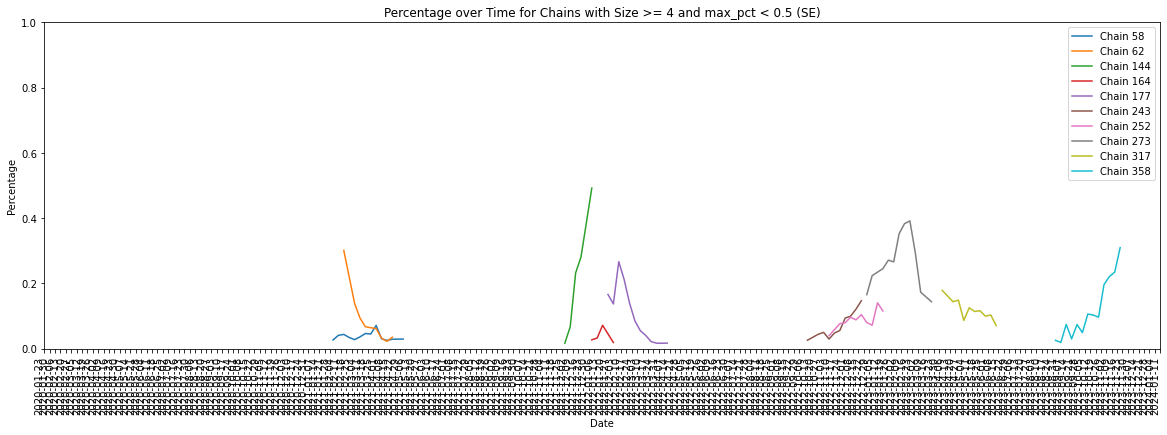

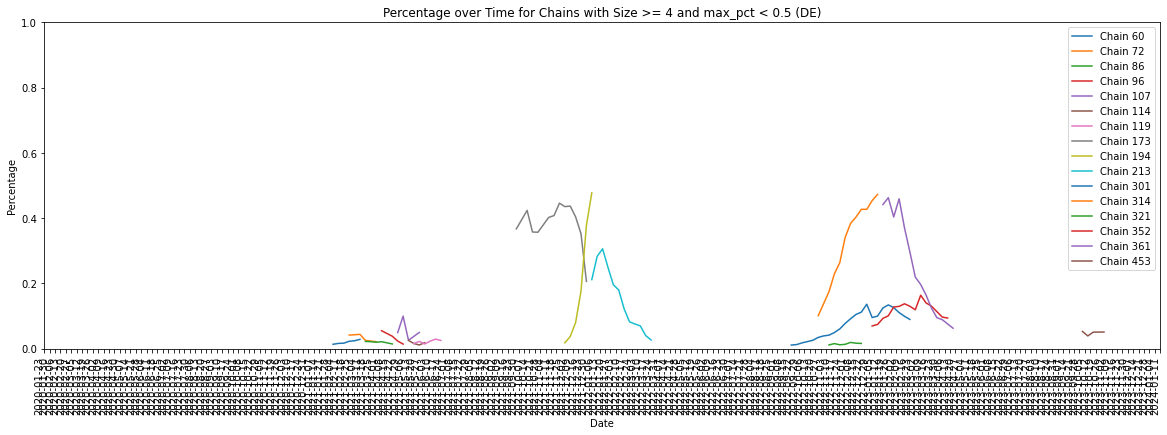

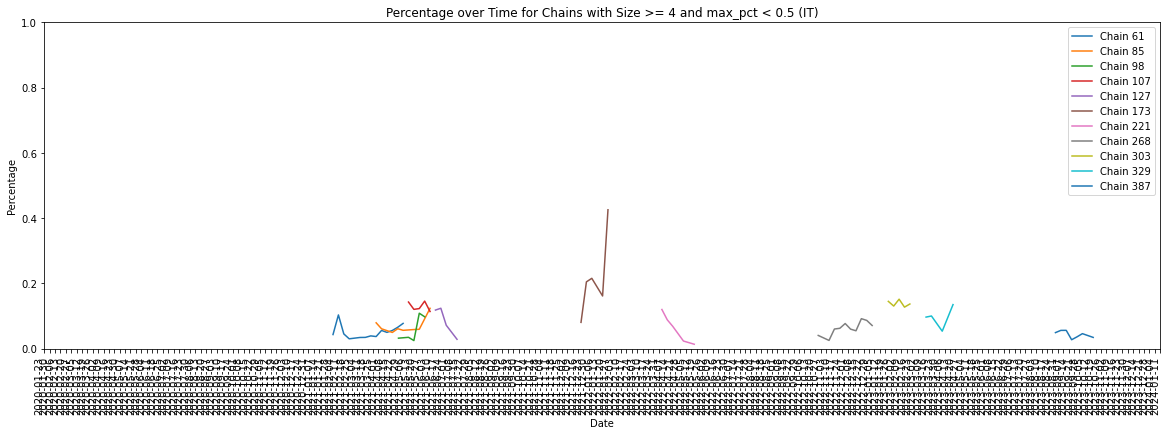

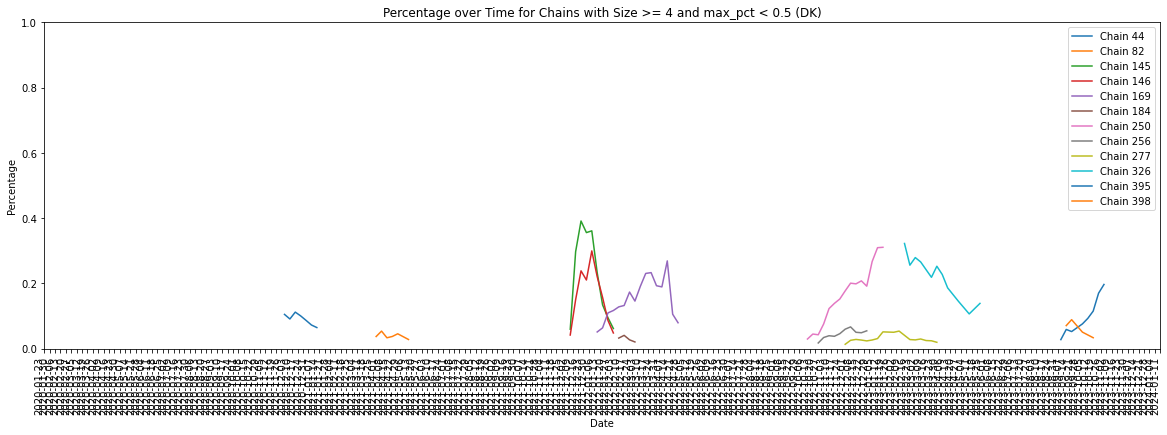

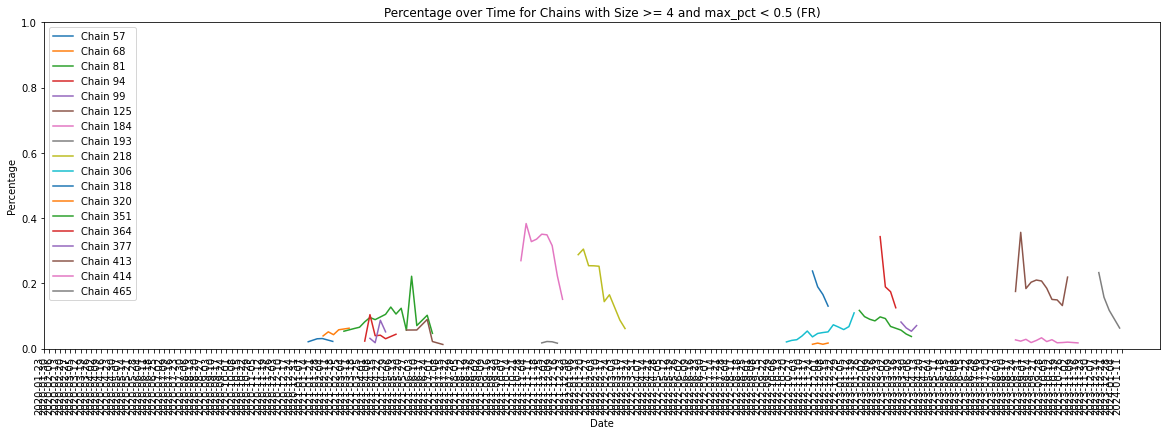

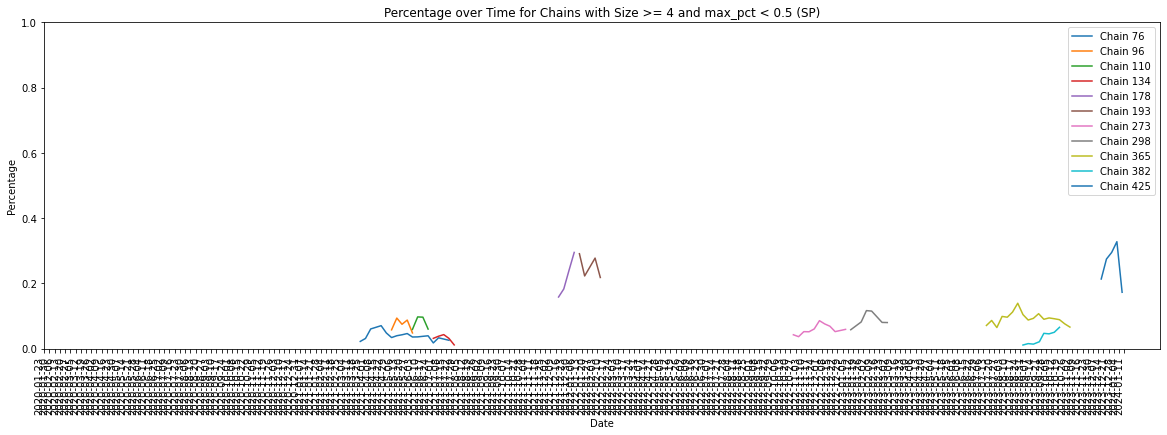

In [2]:
country_list = ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
clustering_file = 'Covid_cluster.csv'
dfs = {}
for country in country_list:
    fold_to_open = 'AIOLOS_2020_' + country
    df_country = pd.read_csv(fold_to_open + '/' + clustering_file)
    df_country['date'] = pd.to_datetime(df_country['date'])
    df_country['country'] = country
    df_country = df_country.sort_values('date')
    dfs[country] = df_country   
start_date = min(df['date'].min() for df in dfs.values())
end_date = max(df['date'].max() for df in dfs.values())
week_dates = [start_date + pd.DateOffset(weeks=x) for x in range((end_date - start_date).days // 7 + 1)]
max_values = df_country.groupby('chain')['pct'].max().reset_index()

for country, df_country in dfs.items():
    max_values = df_country.groupby('chain')['pct'].max().reset_index()
    max_values_filtered = max_values[max_values['pct'] < 0.5]
    df_filtered = df_country[(df_country['chain_size'] >= 4) & (df_country['chain'].isin(max_values_filtered['chain']))]
    grouped_data = df_filtered.groupby('chain')
    fig, ax = plt.subplots(figsize=(20, 6))
    for name, group in grouped_data:
        ax.plot(group['date'], group['pct'], label=f'Chain {name}')
       
    ax.set_xlabel('Date')
    ax.set_ylabel('Percentage')
    ax.set_ylim([0.0, 1])
    ax.legend()
    ax.set_title(f'Percentage over Time for Chains with Size >= 4 and max_pct < 0.5 ({country})')
    ax.set_xticks(week_dates)
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=90, ha="right")  

In [3]:
data_list = []

for country, df_country in dfs.items():
    #filter chains with max_pct <= 0.5 (because we defined 'transient' chains this way)
    max_values = df_country.groupby('chain')['pct'].max().reset_index()
    chains_prevalence_0 = max_values[max_values['pct'] <= 0.5]['chain'].unique() 
    #filter chain with prevalence = 0 (means they are not predominant chains)
    df_prevalence_0 = df_country[df_country['chain'].isin(chains_prevalence_0)]
    #chain_size >= 4
    df_prevalence_0 = df_prevalence_0[df_prevalence_0['chain_size'] >= 4]
    
    for chain in df_prevalence_0['chain'].unique():
        df_chain = df_prevalence_0[df_prevalence_0['chain'] == chain]
        first_week_date = df_chain['date'].min()
        df_weekly = df_chain.set_index('date').resample('W').mean().reset_index()
        weekly_values = df_weekly['pct'].tolist()
        weekly_values_padded = weekly_values[:17] + [None] * (17 - len(weekly_values)) 
        
        data_list.append({
            'chain': chain,
            'country': country,
            'first_week_date': first_week_date,
            **{f'W{i+1}': weekly_values_padded[i] for i in range(17)}
        })

df_result = pd.DataFrame(data_list) #contains chains with prevalence 0 (transient)

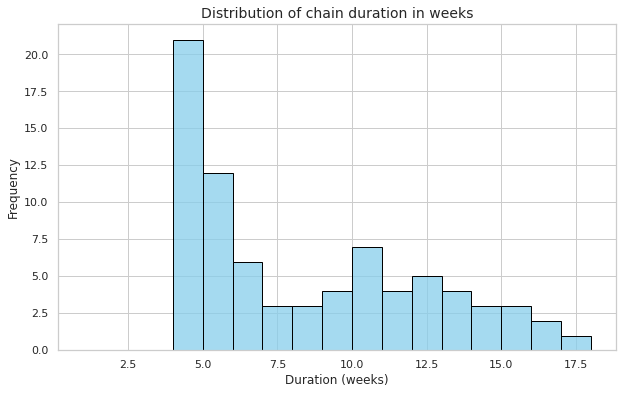

In [4]:
#Let's compute duration of each chain (numbner of weeks with non null values of pct)
df_result['duration_weeks'] = df_result.loc[:, 'W1':'W17'].notnull().sum(axis=1)
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_result['duration_weeks'], bins=range(1, 19), kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of chain duration in weeks', fontsize=14)
plt.xlabel('Duration (weeks)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

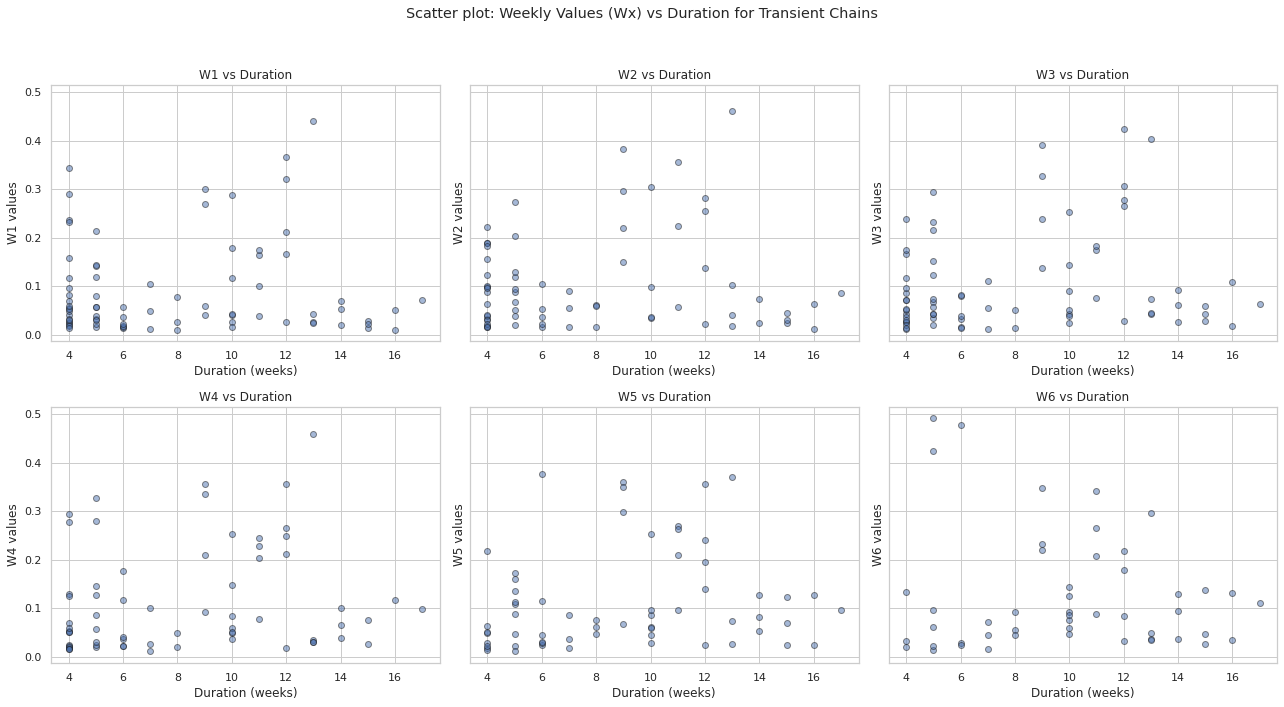

In [5]:
df_result['Duration'] = df_result.apply(lambda row: sum(pd.notna(row[f'W{i+1}']) for i in range(17)), axis=1)
weeks = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Scatter plot: Weekly Values (Wx) vs Duration for Transient Chains")

for i, week in enumerate(weeks):
    ax = axes[i // 3, i % 3]
    ax.scatter(df_result['Duration'], df_result[week], alpha=0.5, edgecolor='k')
    ax.set_title(f'{week} vs Duration')
    ax.set_xlabel('Duration (weeks)')
    ax.set_ylabel(f'{week} values')
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

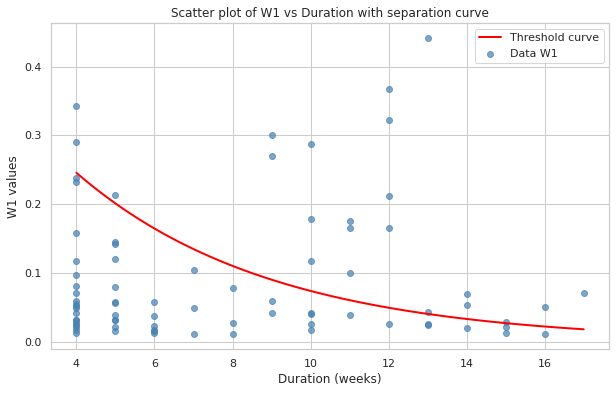

In [6]:
df_result['Duration'] = df_result.apply(lambda row: sum(pd.notnull([row[f'W{i+1}'] for i in range(17)])), axis=1)
df_filtered = df_result[['Duration', 'W1']].dropna()

def threshold_curve(duration, a=0.3, b=0.2):
    return a * np.exp(-b * (duration - 3))

x_threshold = np.linspace(df_filtered['Duration'].min(), df_filtered['Duration'].max(), 100)
y_threshold = threshold_curve(x_threshold)

plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['Duration'], df_filtered['W1'], color='steelblue', alpha=0.7, label='Data W1')
plt.plot(x_threshold, y_threshold, color='red', linestyle='-', linewidth=2, label='Threshold curve')
plt.title('Scatter plot of W1 vs Duration with separation curve')
plt.xlabel('Duration (weeks)')
plt.ylabel('W1 values')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
df_result['threshold_value'] = threshold_curve(df_result['Duration'])
df_above_threshold = df_result[df_result['W1'] > df_result['threshold_value']]
df_below_threshold = df_result[df_result['W1'] <= df_result['threshold_value']]
num_above_threshold = len(df_above_threshold)
num_below_threshold = len(df_below_threshold)
print(f"Numb. of chains above threshold: {num_above_threshold}")
print(f"Numb. of chains below threshold: {num_below_threshold}") #so that later we can generate chains according to these number for the two categories

Numb. of chains above threshold: 22
Numb. of chains below threshold: 56


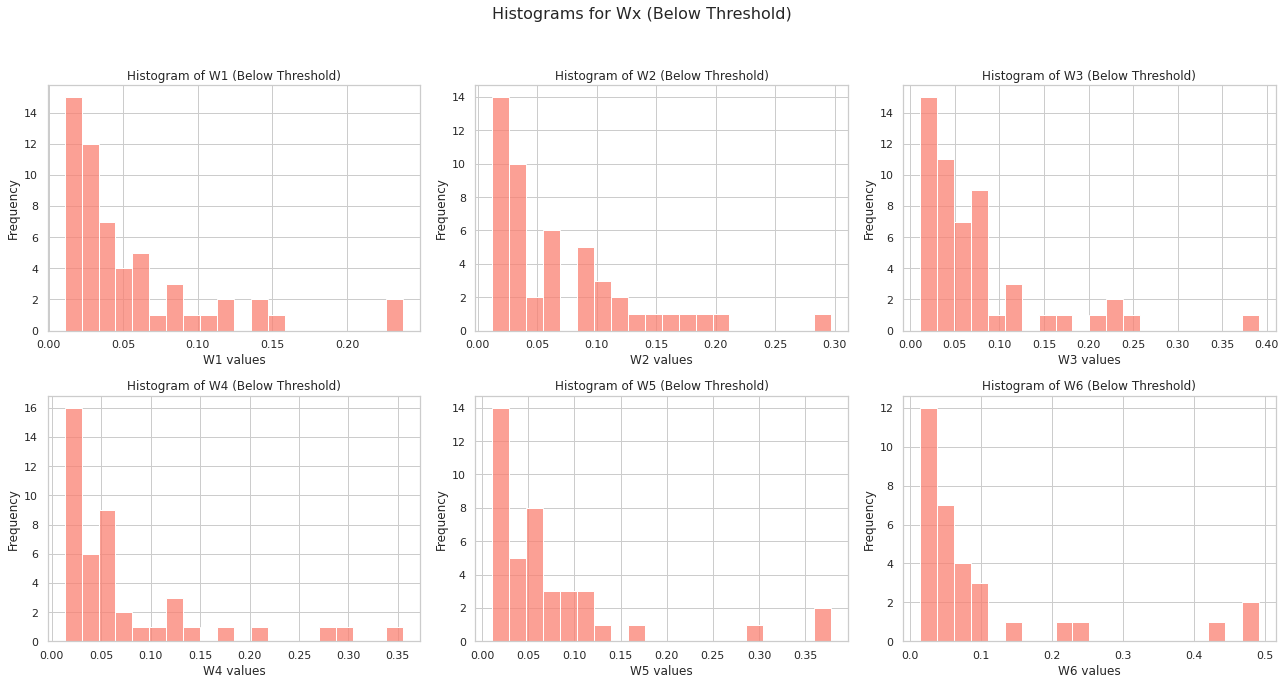

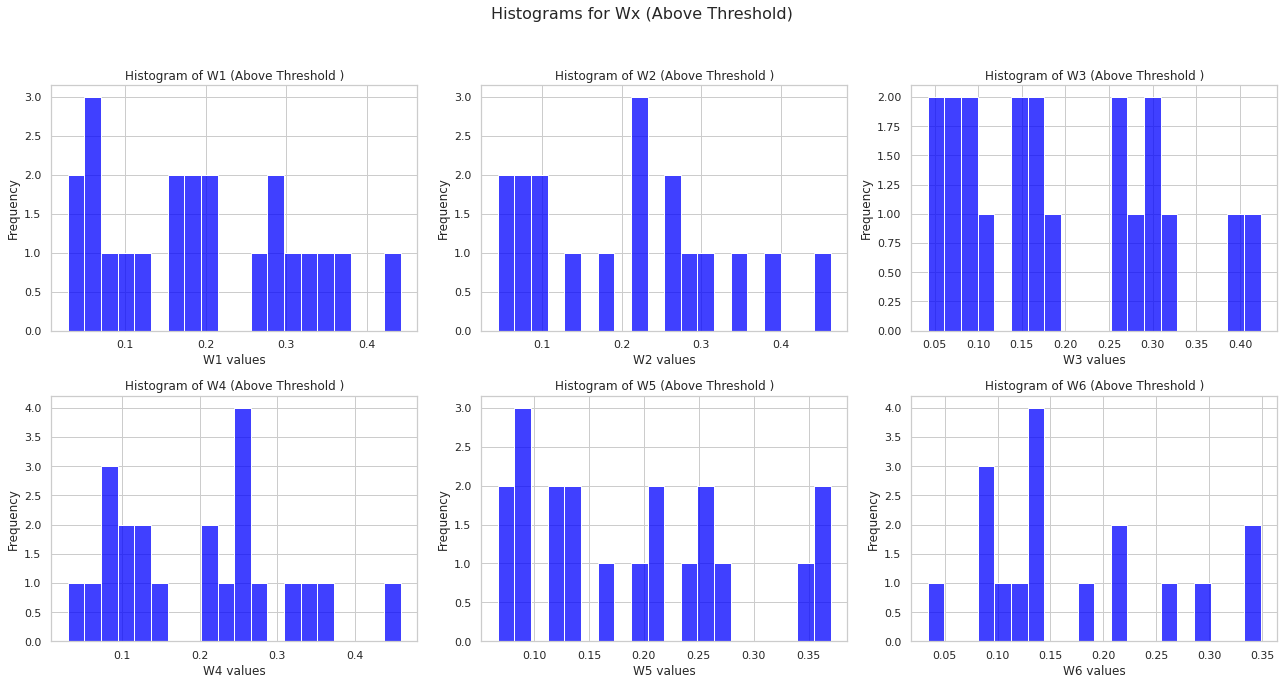

In [7]:
#compute duration in terms of weeks (values of Wx (percentage of prevalence of the sequence of that chain at week x) not null)
df_result['Duration'] = df_result.apply(lambda row: sum(pd.notnull([row[f'W{i+1}'] for i in range(17)])), axis=1)

#we define a curve as threshold
def threshold_curve(duration, a=0.3, b=0.2):
    return a * np.exp(-b * (duration - 3))

#calculate the threshold value for each value of Duration
df_result['threshold_value'] = threshold_curve(df_result['Duration'])

#split real transient chains data according to the threshold as "below" or "above"
df_above_threshold = df_result[df_result['W1'] > df_result['threshold_value']]
df_below_threshold = df_result[df_result['W1'] <= df_result['threshold_value']]
weeks_to_plot = [f'W{i+1}' for i in range(6)]

#below threshold plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Histograms for Wx (Below Threshold)', fontsize=16)

for i, week in enumerate(weeks_to_plot):
    sns.histplot(df_below_threshold[week], bins=20, kde=False, ax=axes[i // 3, i % 3], color='salmon')
    axes[i // 3, i % 3].set_title(f'Histogram of {week} (Below Threshold)')
    axes[i // 3, i % 3].set_xlabel(f'{week} values')
    axes[i // 3, i % 3].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#above threshold plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Histograms for Wx (Above Threshold)', fontsize=16)

for i, week in enumerate(weeks_to_plot):
    sns.histplot(df_above_threshold[week], bins=20, kde=False, ax=axes[i // 3, i % 3], color='blue')
    axes[i // 3, i % 3].set_title(f'Histogram of {week} (Above Threshold )')
    axes[i // 3, i % 3].set_xlabel(f'{week} values')
    axes[i // 3, i % 3].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

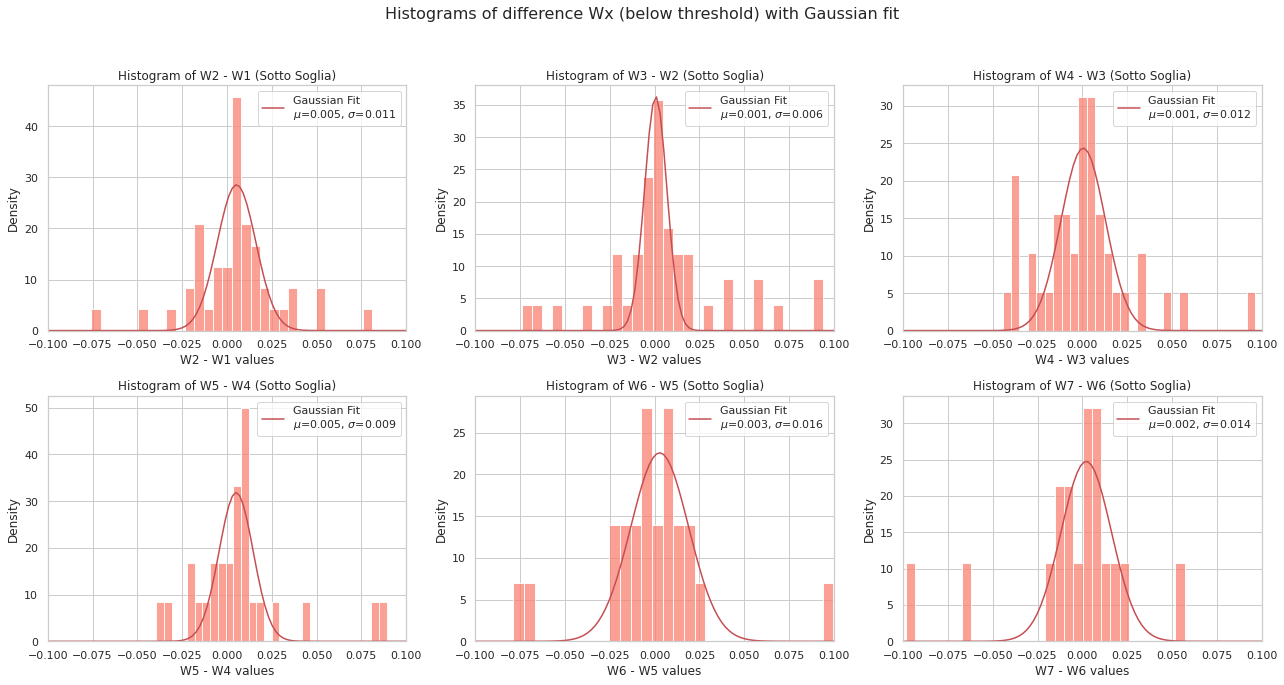

In [8]:
def gaussian(x, mu, sigma, amplitude):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

#list of differences to compute (W2 - W1, W3 - W2, ..., W7 - W6)
weeks_diffs = [(f'W{i+1}', f'W{i}') for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Histograms of difference Wx (below threshold) with Gaussian fit', fontsize=16)

for i, (week_curr, week_prev) in enumerate(weeks_diffs):
    diff_values = df_below_threshold[week_curr] - df_below_threshold[week_prev]
    diff_values = diff_values[(diff_values >= -0.10) & (diff_values <= 0.10)]
    sns.histplot(diff_values, bins=30, kde=False, ax=axes[i // 3, i % 3], color='salmon', stat='density')
    axes[i // 3, i % 3].set_title(f'Histogram of {week_curr} - {week_prev} (Sotto Soglia)')
    axes[i // 3, i % 3].set_xlabel(f'{week_curr} - {week_prev} values')
    axes[i // 3, i % 3].set_ylabel('Density')
    axes[i // 3, i % 3].set_xlim(-0.10, 0.10)
    counts, bin_edges = np.histogram(diff_values, bins=30, range=(-0.10, 0.10), density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    mu_initial = diff_values.mean()
    sigma_initial = diff_values.std()
    amplitude_initial = max(counts)

    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[mu_initial, sigma_initial, amplitude_initial])
        mu_fit, sigma_fit, amplitude_fit = popt
        x_values = np.linspace(-0.10, 0.10, 100)
        gauss_fit = gaussian(x_values, mu_fit, sigma_fit, amplitude_fit)
        axes[i // 3, i % 3].plot(x_values, gauss_fit, 'r-', label=f'Gaussian Fit\n$\mu$={mu_fit:.3f}, $\sigma$={sigma_fit:.3f}')
        axes[i // 3, i % 3].legend()
    except RuntimeError:
        print(f"Gaussian fit did not converge for {week_curr} - {week_prev}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

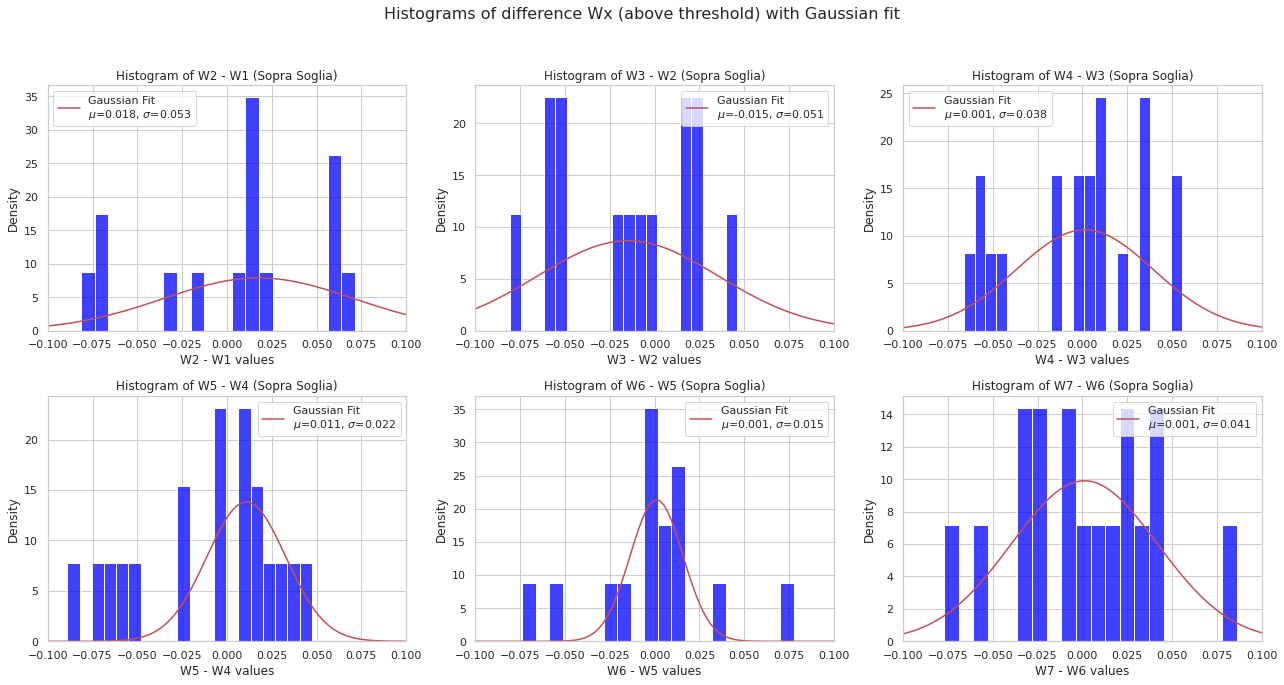

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Histograms of difference Wx (above threshold) with Gaussian fit', fontsize=16)

for i, (week_curr, week_prev) in enumerate(weeks_diffs):
    diff_values = df_above_threshold[week_curr] - df_above_threshold[week_prev]
    diff_values = diff_values[(diff_values >= -0.10) & (diff_values <= 0.10)]
    sns.histplot(diff_values, bins=20, kde=False, ax=axes[i // 3, i % 3], color='blue', stat='density')
    axes[i // 3, i % 3].set_title(f'Histogram of {week_curr} - {week_prev} (Sopra Soglia)')
    axes[i // 3, i % 3].set_xlabel(f'{week_curr} - {week_prev} values')
    axes[i // 3, i % 3].set_ylabel('Density')
    axes[i // 3, i % 3].set_xlim(-0.10, 0.10)
    counts, bin_edges = np.histogram(diff_values, bins=20, range=(-0.10, 0.10), density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    mu_initial = diff_values.mean()
    sigma_initial = diff_values.std()
    amplitude_initial = max(counts)

    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[mu_initial, sigma_initial, amplitude_initial])
        mu_fit, sigma_fit, amplitude_fit = popt
        x_fit = np.linspace(-0.10, 0.10, 100)
        y_fit = gaussian(x_fit, mu_fit, sigma_fit, amplitude_fit)
        axes[i // 3, i % 3].plot(x_fit, y_fit, 'r-', label=f'Gaussian Fit\n$\mu$={mu_fit:.3f}, $\sigma$={sigma_fit:.3f}')
        axes[i // 3, i % 3].legend()
    except RuntimeError:
        print(f"Il fit gaussiano non è riuscito a convergere per {week_curr} - {week_prev}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
#chain generation for each of the two groups
n_chains_below_threshold = 7600
n_chains_above_threshold = 2400  

diff_means_below = {'W2-W1': 0.005, 'W3-W2': 0.001, 'W4-W3': 0.001, 'W5-W4': 0.005, 'W6-W5': 0.003, 'W7-W6': 0.002}
diff_stds_below = {'W2-W1': 0.011, 'W3-W2': 0.006, 'W4-W3': 0.012, 'W5-W4': 0.009, 'W6-W5': 0.0, 'W7-W6': 0.02}
diff_means_above = {'W2-W1': 0.04, 'W3-W2': 0.05, 'W4-W3': 0.06, 'W5-W4': 0.05, 'W6-W5': 0.04, 'W7-W6': 0.05}
diff_stds_above = {'W2-W1': 0.02, 'W3-W2': 0.03, 'W4-W3': 0.02, 'W5-W4': 0.03, 'W6-W5': 0.02, 'W7-W6': 0.03}

#parameters for W1 from the real chains
w1_mean_below = 0.01 
w1_std_below = 0.005
w1_mean_above = 0.2 
w1_std_above = 0.02

def generate_chains_with_realistic_W1(n_chains, w1_mean, w1_std, means, stds, label):
    chains = []
    for _ in range(n_chains):
        w1 = max(np.random.normal(w1_mean, w1_std), 0)  # Assicura che W1 sia >= 0
        chain = [w1]
        
        for week in range(1, 7):  # Da W2 a W7
            diff_label = f'W{week+1}-W{week}'
            diff = np.random.normal(means[diff_label], stds[diff_label])
            diff = max(diff, 0)  # Assicura che la differenza sia >= 0
            
            next_value = chain[-1] + diff
            
            if next_value <= 0:
                chain.extend([0] * (7 - len(chain)))  # Riempie i restanti con 0
                break
            else:
                chain.append(next_value)
        
        chains.append(chain)
    
    df = pd.DataFrame(chains, columns=[f'W{i}' for i in range(1, 8)])
    df['label'] = label
    return df

df_below_threshold_simulated = generate_chains_with_realistic_W1(
    n_chains_below_threshold, w1_mean_below, w1_std_below, diff_means_below, diff_stds_below, 'below threshold'
)
df_above_threshold_simulated = generate_chains_with_realistic_W1(
    n_chains_above_threshold, w1_mean_above, w1_std_above, diff_means_above, diff_stds_above, 'above threshold'
)
df_simulated = pd.concat([df_below_threshold_simulated, df_above_threshold_simulated], ignore_index=True)
print(df_simulated)

            W1        W2        W3        W4        W5        W6        W7  \
0     0.015826  0.035638  0.046310  0.046310  0.055214  0.058214  0.058214   
1     0.009491  0.009491  0.019702  0.030273  0.039358  0.042358  0.086401   
2     0.025429  0.028451  0.028451  0.042849  0.045356  0.048356  0.048356   
3     0.015148  0.032517  0.032517  0.050799  0.060414  0.063414  0.063414   
4     0.000027  0.000027  0.014521  0.036638  0.039148  0.042148  0.065588   
...        ...       ...       ...       ...       ...       ...       ...   
9995  0.195124  0.249286  0.273337  0.298673  0.344546  0.369933  0.402869   
9996  0.207171  0.252465  0.308174  0.369344  0.408522  0.434909  0.469539   
9997  0.201864  0.205484  0.231713  0.295557  0.359172  0.426070  0.492964   
9998  0.189598  0.255719  0.302318  0.393339  0.409754  0.451472  0.538616   
9999  0.189755  0.236425  0.300345  0.380241  0.455557  0.507451  0.618715   

                label  
0     below threshold  
1     below thr

In [11]:
df_simulated['label'] = df_simulated['label'].replace({'above threshould': 3, 'below threshold': 2})
print(df_simulated)

            W1        W2        W3        W4        W5        W6        W7  \
0     0.015826  0.035638  0.046310  0.046310  0.055214  0.058214  0.058214   
1     0.009491  0.009491  0.019702  0.030273  0.039358  0.042358  0.086401   
2     0.025429  0.028451  0.028451  0.042849  0.045356  0.048356  0.048356   
3     0.015148  0.032517  0.032517  0.050799  0.060414  0.063414  0.063414   
4     0.000027  0.000027  0.014521  0.036638  0.039148  0.042148  0.065588   
...        ...       ...       ...       ...       ...       ...       ...   
9995  0.195124  0.249286  0.273337  0.298673  0.344546  0.369933  0.402869   
9996  0.207171  0.252465  0.308174  0.369344  0.408522  0.434909  0.469539   
9997  0.201864  0.205484  0.231713  0.295557  0.359172  0.426070  0.492964   
9998  0.189598  0.255719  0.302318  0.393339  0.409754  0.451472  0.538616   
9999  0.189755  0.236425  0.300345  0.380241  0.455557  0.507451  0.618715   

                label  
0                   2  
1              

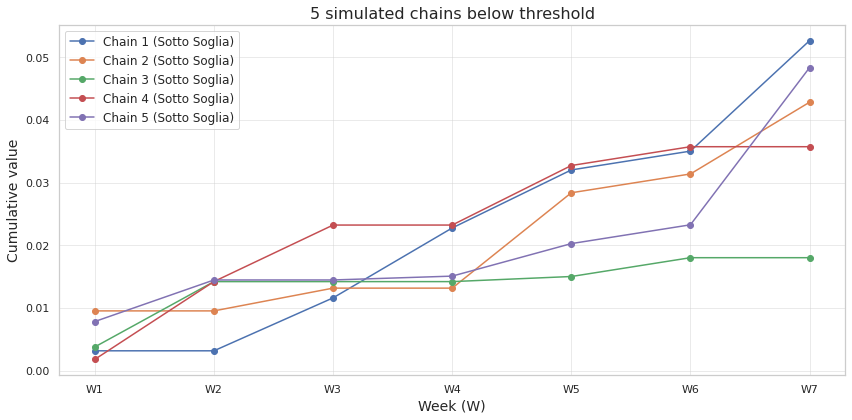

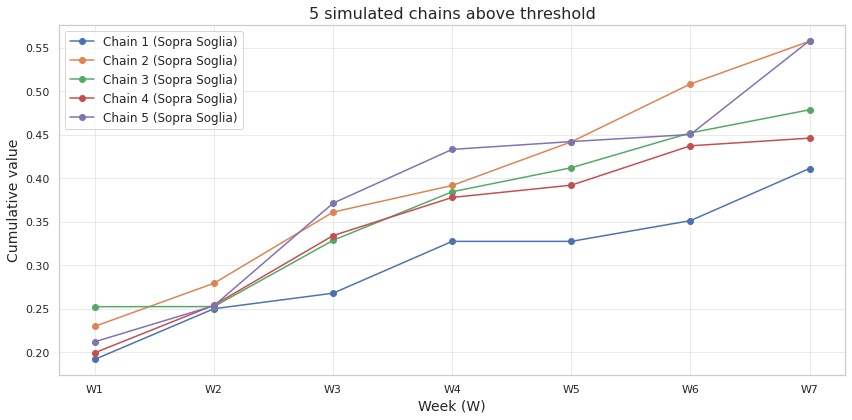

In [12]:
plt.figure(figsize=(12, 6))
random_chains_below = df_below_threshold_simulated.sample(n=5, random_state=42)
for idx in range(len(random_chains_below)):
    plt.plot(range(1, 8), random_chains_below.iloc[idx, :-1], marker='o', label=f'Chain {idx + 1} (Sotto Soglia)')

plt.title('5 simulated chains below threshold', fontsize=16)
plt.xlabel('Week (W)', fontsize=14)
plt.ylabel('Cumulative value', fontsize=14)
plt.xticks(range(1, 8), labels=[f'W{i}' for i in range(1, 8)])
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
random_chains_above = df_above_threshold_simulated.sample(n=5, random_state=42)
for idx in range(len(random_chains_above)):
    plt.plot(range(1, 8), random_chains_above.iloc[idx, :-1], marker='o', label=f'Chain {idx + 1} (Sopra Soglia)')

plt.title('5 simulated chains above threshold', fontsize=16)
plt.xlabel('Week (W)', fontsize=14)
plt.ylabel('Cumulative value', fontsize=14)
plt.xticks(range(1, 8), labels=[f'W{i}' for i in range(1, 8)])
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
df_simulated['chain'] = range(1, 10001)  # Assuming chain numbers for simulated chains are 1-10000
df_selected = df_simulated[['chain', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'label']]
print(df_selected)

def sigmoid(t, a, b, L):
    return L / (1 + np.exp(-a * (t - b)))

def fit_sigmoid(t_values, pct_values):
    if any([np.isnan(x) or np.isinf(x) for x in pct_values]):
        return [np.nan, np.nan, np.nan] 
    initial_guess = [0.5, np.mean(t_values), max(pct_values)]
    bounds = ([0, 0, 0], [10, max(t_values) * 1.5, max(pct_values) * 1.5])

    try:
        popt, _ = curve_fit(sigmoid, t_values, pct_values, p0=initial_guess, bounds=bounds, maxfev=10000)
    except (RuntimeError, ValueError):
        popt = [np.nan, np.nan, np.nan] 
    return popt

for idx, row in df_selected.iterrows():
    if row[['W1', 'W2', 'W3']].isnull().any():
        df_selected.at[idx, 'a3'] = np.nan
        df_selected.at[idx, 'b3'] = np.nan
        df_selected.at[idx, 'L3'] = np.nan
        continue

    t_values_3 = [1, 2, 3]
    pct_values_3 = [row['W1'], row['W2'], row['W3']]
    a3, b3, L3 = fit_sigmoid(t_values_3, pct_values_3)
    df_selected.at[idx, 'a3'] = a3
    df_selected.at[idx, 'b3'] = b3
    df_selected.at[idx, 'L3'] = L3

    if not pd.isna(row['W4']):  
        t_values_4 = [1, 2, 3, 4]
        pct_values_4 = pct_values_3 + [row['W4']]
        a4, b4, L4 = fit_sigmoid(t_values_4, pct_values_4)
        df_selected.at[idx, 'a4'] = a4
        df_selected.at[idx, 'b4'] = b4
        df_selected.at[idx, 'L4'] = L4
    else:
        df_selected.at[idx, 'a4'] = np.nan
        df_selected.at[idx, 'b4'] = np.nan
        df_selected.at[idx, 'L4'] = np.nan

    if not pd.isna(row['W5']):  
        t_values_5 = [1, 2, 3, 4, 5]
        pct_values_5 = pct_values_4 + [row['W5']]
        a5, b5, L5 = fit_sigmoid(t_values_5, pct_values_5)
        df_selected.at[idx, 'a5'] = a5
        df_selected.at[idx, 'b5'] = b5
        df_selected.at[idx, 'L5'] = L5
    else:
        df_selected.at[idx, 'a5'] = np.nan
        df_selected.at[idx, 'b5'] = np.nan
        df_selected.at[idx, 'L5'] = np.nan

df_selected['a'] = -999
df_selected['b'] = -999
df_selected['L'] = -999

df_selected.to_csv('simulated_transient_chains.csv', index=False)
print(df_selected.head())

      chain        W1        W2        W3        W4        W5        W6  \
0         1  0.015826  0.035638  0.046310  0.046310  0.055214  0.058214   
1         2  0.009491  0.009491  0.019702  0.030273  0.039358  0.042358   
2         3  0.025429  0.028451  0.028451  0.042849  0.045356  0.048356   
3         4  0.015148  0.032517  0.032517  0.050799  0.060414  0.063414   
4         5  0.000027  0.000027  0.014521  0.036638  0.039148  0.042148   
...     ...       ...       ...       ...       ...       ...       ...   
9995   9996  0.195124  0.249286  0.273337  0.298673  0.344546  0.369933   
9996   9997  0.207171  0.252465  0.308174  0.369344  0.408522  0.434909   
9997   9998  0.201864  0.205484  0.231713  0.295557  0.359172  0.426070   
9998   9999  0.189598  0.255719  0.302318  0.393339  0.409754  0.451472   
9999  10000  0.189755  0.236425  0.300345  0.380241  0.455557  0.507451   

            W7            label  
0     0.058214                2  
1     0.086401                2

/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/pandas/core/indexing.py:1596: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = _infer_fill_value(value)
/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/pandas/core/indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

   chain        W1        W2        W3        W4        W5        W6  \
0      1  0.015826  0.035638  0.046310  0.046310  0.055214  0.058214   
1      2  0.009491  0.009491  0.019702  0.030273  0.039358  0.042358   
2      3  0.025429  0.028451  0.028451  0.042849  0.045356  0.048356   
3      4  0.015148  0.032517  0.032517  0.050799  0.060414  0.063414   
4      5  0.000027  0.000027  0.014521  0.036638  0.039148  0.042148   

         W7 label        a3  ...        L3        a4        b4        L4  \
0  0.058214     2  1.692287  ...  0.049666  1.863078  1.379765  0.047433   
1  0.086401     2  0.767682  ...  0.029553  0.800969  3.270745  0.045410   
2  0.048356     2  0.280539  ...  0.042676  0.331093  2.678538  0.064273   
3  0.063414     2  9.141079  ...  0.032519  0.595488  3.025685  0.076198   
4  0.065588     2  8.070229  ...  0.017378  6.781786  3.062470  0.036702   

         a5        b5        L5    a    b    L  
0  1.442356  1.526146  0.051919 -999 -999 -999  
1  0.687060 